# 03 · Campaign analysis: defining virality and the revenue spike

Two questions:
1. **Which campaigns truly went viral?** — a definition based on reach *and* organic amplification,
   not an arbitrary view count.
2. **How much immediate revenue follows virality?** — an event-time analysis around each campaign date.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from metrics import add_virality
import viz; viz.setup()
pd.set_option("display.width", 180, "display.max_columns", 40)

c = pd.read_csv("../data/processed/campaigns.csv", parse_dates=["campaign_date"])
cu = pd.read_csv("../data/processed/customers.csv", parse_dates=["acquisition_date", "first_purchase_date"])
o = pd.read_csv("../data/processed/orders.csv", parse_dates=["order_date"])
s = pd.read_csv("../data/processed/sessions.csv", parse_dates=["timestamp"])

## 1. Defining "viral"

```
share rate      = shares / reach
save rate       = saves / reach
engagement rate = (likes + comments + shares + saves) / reach

viral  ⇔  reach ≥ 90th percentile  AND  share rate ≥ 75th percentile
virality score = z(log reach) + z(log share rate)          (continuous version)
```
Reach captures distribution; share rate captures people actively spreading the content. A campaign
with huge paid reach but no sharing is "high reach, low sharing", not viral.

In [2]:
c = add_virality(c)
thr_reach, thr_share = c.reach.quantile(0.9), c.share_rate.quantile(0.75)
print(f"reach threshold (p90)      : {thr_reach:,.0f}")
print(f"share-rate threshold (p75) : {thr_share:.3%}")
print(c.virality_tier.value_counts().to_string())

reach threshold (p90)      : 1,259,975
share-rate threshold (p75) : 0.937%
virality_tier
Standard                   108
Viral                        8
High reach, low sharing      4


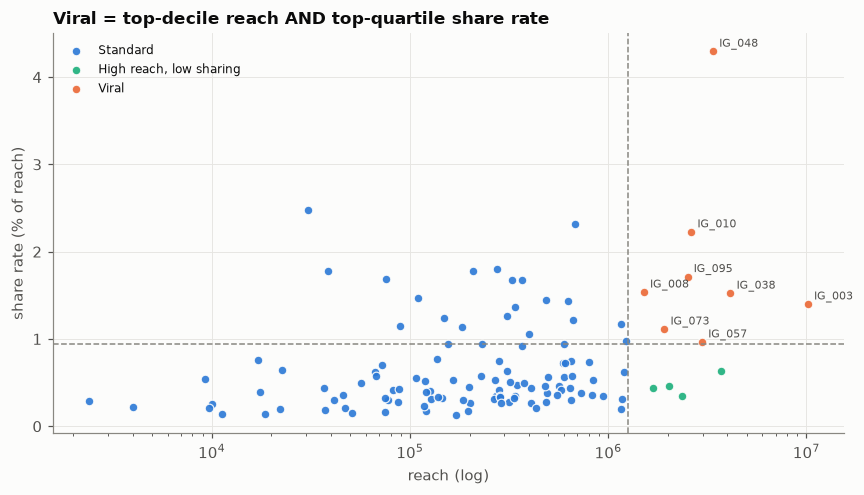

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for tier, col in [("Standard", viz.SERIES[0]), ("High reach, low sharing", viz.SERIES[2]), ("Viral", viz.VIRAL)]:
    d = c[c.virality_tier == tier]
    ax.scatter(d.reach, d.share_rate * 100, s=32, color=col, label=tier, alpha=0.9, edgecolor=viz.SURFACE, linewidth=0.8)
ax.axvline(thr_reach, color=viz.MUTED, linestyle="--", linewidth=1); ax.axhline(thr_share * 100, color=viz.MUTED, linestyle="--", linewidth=1)
for _, r in c[c.is_viral == 1].iterrows():
    ax.annotate(r.campaign_id, (r.reach, r.share_rate * 100), fontsize=7, xytext=(4, 3), textcoords="offset points", color=viz.INK2)
ax.set_xscale("log"); ax.set_xlabel("reach (log)"); ax.set_ylabel("share rate (% of reach)")
ax.set_title("Viral = top-decile reach AND top-quartile share rate"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("../images/03_viral_definition.png"); plt.show()

In [4]:
viral = c[c.is_viral == 1].sort_values("reach", ascending=False)
viral[["campaign_id", "campaign_date", "campaign_type", "content_type", "creator_tier", "discount_pct",
       "reach", "shares", "saves", "share_rate", "save_rate", "follower_gain", "spend"]].round(4)

,campaign_id,campaign_date,campaign_type,content_type,creator_tier,discount_pct,reach,shares,saves,share_rate,save_rate,follower_gain,spend
2,IG_003,2025-01-11,Influencer,Reel,Macro,0,10191099,142638,30542,0.0140,0.0030,45336,24736.95
37,IG_038,2025-03-25,Paid Amplification,Carousel,Brand,15,4143880,63127,86250,0.0152,0.0208,36559,31227.49
47,IG_048,2025-04-24,Discount,Reel,Brand,25,3386549,145458,10977,0.0430,0.0032,27506,11922.41
56,IG_057,2025-05-06,Influencer,Reel,Mega,0,2980958,28764,23298,0.0096,0.0078,10492,83249.44
9,IG_010,2025-01-30,Paid Amplification,Reel,Brand,15,2628990,58521,7156,0.0223,0.0027,14465,45202.63
94,IG_095,2025-07-14,Influencer,Reel,Macro,10,2518133,43156,5389,0.0171,0.0021,11115,33052.58
72,IG_073,2025-06-05,Paid Amplification,Carousel,Brand,15,1923216,21392,6957,0.0111,0.0036,7897,38852.08
7,IG_008,2025-01-27,Organic,Reel,Brand,0,1516158,23292,9563,0.0154,0.0063,14914,3987.28


The viral set is not one thing: it mixes an organic community Reel, macro/mega influencer Reels, paid
carousels and a 25%-off discount Reel. Their **save rates differ by an order of magnitude** even though
their share rates are similar. That heterogeneity is what we will exploit later.

## 2. What kind of campaigns go viral?

In [5]:
pd.crosstab(c.campaign_type, c.virality_tier).assign(viral_share=lambda d: (d["Viral"] / d.sum(axis=1)).round(2))

virality_tier,"High reach, low sharing",Standard,Viral,viral_share
campaign_type,,,,
Discount,0,14,1,0.07
Influencer,1,39,3,0.07
Organic,0,15,1,0.06
Paid Amplification,2,15,3,0.15
Product Drop,1,14,0,0.00
UGC,0,11,0,0.00


In [6]:
pd.crosstab(c.content_type, c.virality_tier)

virality_tier,"High reach, low sharing",Standard,Viral
content_type,,,
Carousel,0,18,2
Live,0,4,0
Reel,4,53,6
Static Post,0,11,0
Story,0,22,0


## 3. Acquisition funnel by virality tier

Sessions per 1,000 reach (click-through) and on-site conversion, pooled per tier.

In [7]:
f = s[s.traffic_source == "instagram_campaign"].merge(c[["campaign_id", "virality_tier", "reach"]], on="campaign_id")
fun = f.groupby("virality_tier").agg(sessions=("session_id", "size"), atc=("add_to_cart", "sum"),
                                     checkout=("checkout_started", "sum"), purchases=("purchase", "sum"))
fun["reach"] = c.groupby("virality_tier").reach.sum()
fun["sessions_per_1k_reach"] = fun.sessions / fun.reach * 1000
fun["session_conversion"] = fun.purchases / fun.sessions
fun["customers_per_1k_reach"] = fun.purchases / fun.reach * 1000
fun.round(4)

,sessions,atc,checkout,purchases,reach,sessions_per_1k_reach,session_conversion,customers_per_1k_reach
virality_tier,,,,,,,,
"High reach, low sharing",103769,24739,11328,6292,9798900,10.5899,0.0606,0.6421
Standard,443145,98231,45433,25516,34432340,12.8700,0.0576,0.7410
Viral,184233,35563,16471,9139,29288983,6.2902,0.0496,0.3120


Viral campaigns convert **less of their reach into visits and purchases** than standard campaigns: the
audience beyond the core following is less qualified ("audience dilution"). They still acquire more
customers in absolute terms because the reach is so much larger.

## 4. The revenue spike — event-time analysis

For each campaign, align the cohort's daily net revenue to the campaign date (day 0) and look at
days −7 … +30. We index each series to the cohort's own peak so campaigns of different size can be compared.

In [8]:
oc = o.merge(cu[["customer_id", "acquisition_campaign"]], on="customer_id") \
      .merge(c[["campaign_id", "campaign_date", "virality_tier", "is_viral"]], left_on="acquisition_campaign", right_on="campaign_id")
oc["t"] = (oc.order_date - oc.campaign_date).dt.days
ev = oc[(oc.t >= 0) & (oc.t <= 60)].groupby(["campaign_id", "t"]).net_revenue.sum().unstack(fill_value=0)
ev = ev.reindex(columns=range(0, 61), fill_value=0)
share_first7 = ev.loc[:, :7].sum(axis=1) / ev.sum(axis=1)
c["revenue_share_first7_of_60"] = c.campaign_id.map(share_first7)
c.groupby("virality_tier").revenue_share_first7_of_60.describe()[["count", "mean", "50%"]].round(3)

,count,mean,50%
virality_tier,,,
"High reach, low sharing",4.0,0.575,0.565
Standard,108.0,0.657,0.642
Viral,8.0,0.691,0.692


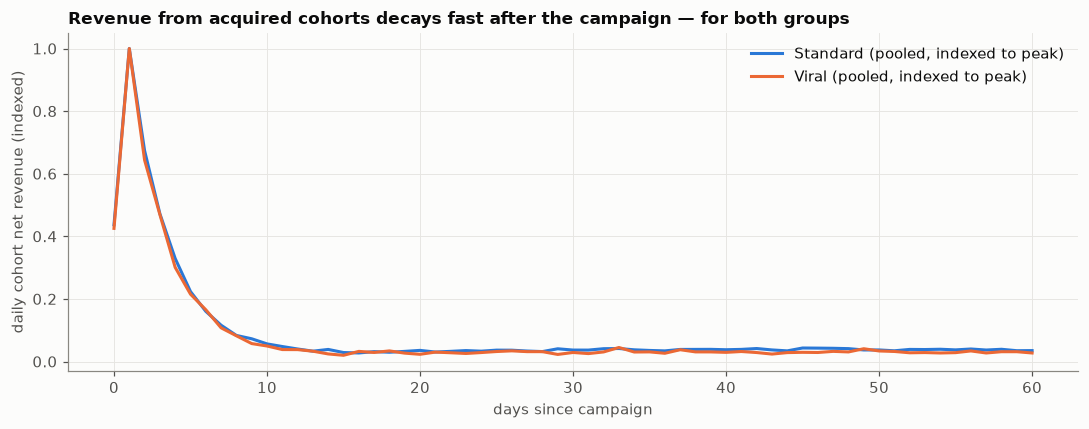

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for tier, col in [("Standard", viz.SERIES[0]), ("Viral", viz.VIRAL)]:
    ids = c[c.virality_tier == tier].campaign_id
    curve = ev.loc[ev.index.isin(ids)].sum(axis=0)
    ax.plot(curve.index, curve.values / curve.values.max(), color=col, label=f"{tier} (pooled, indexed to peak)")
ax.set_xlabel("days since campaign"); ax.set_ylabel("daily cohort net revenue (indexed)")
ax.set_title("Revenue from acquired cohorts decays fast after the campaign — for both groups"); ax.legend()
plt.tight_layout(); plt.savefig("../images/03_event_time_revenue.png"); plt.show()

## 5. Short-term scorecard: 7-day revenue, ROAS, CAC, new customers

In [10]:
wk = oc[oc.t <= 7].groupby("campaign_id").agg(revenue_7d=("net_revenue", "sum"), orders_7d=("order_id", "size"))
nc = cu.groupby("acquisition_campaign").size().rename("new_customers")
sc = c.merge(wk, on="campaign_id", how="left").merge(nc, left_on="campaign_id", right_index=True, how="left").fillna({"revenue_7d": 0, "new_customers": 0})
sc["roas_7d"] = sc.revenue_7d / sc.spend
sc["cac"] = sc.spend / sc.new_customers.replace(0, np.nan)
sc["cost_per_1k_reach"] = sc.spend / sc.reach * 1000
short = sc.groupby("virality_tier").agg(campaigns=("campaign_id", "size"), spend=("spend", "sum"), reach=("reach", "sum"),
                                        new_customers=("new_customers", "sum"), revenue_7d=("revenue_7d", "sum"))
short["roas_7d_pooled"] = short.revenue_7d / short.spend
short["cac_pooled"] = short.spend / short.new_customers
short["cost_per_1k_reach"] = short.spend / short.reach * 1000
short.round(2)

,campaigns,spend,reach,new_customers,revenue_7d,roas_7d_pooled,cac_pooled,cost_per_1k_reach
virality_tier,,,,,,,,
"High reach, low sharing",4,111665.25,9798900,6292,473086.02,4.24,17.75,11.40
Standard,108,1312967.41,34432340,25516,2205790.58,1.68,51.46,38.13
Viral,8,272230.86,29288983,9139,803859.66,2.95,29.79,9.29


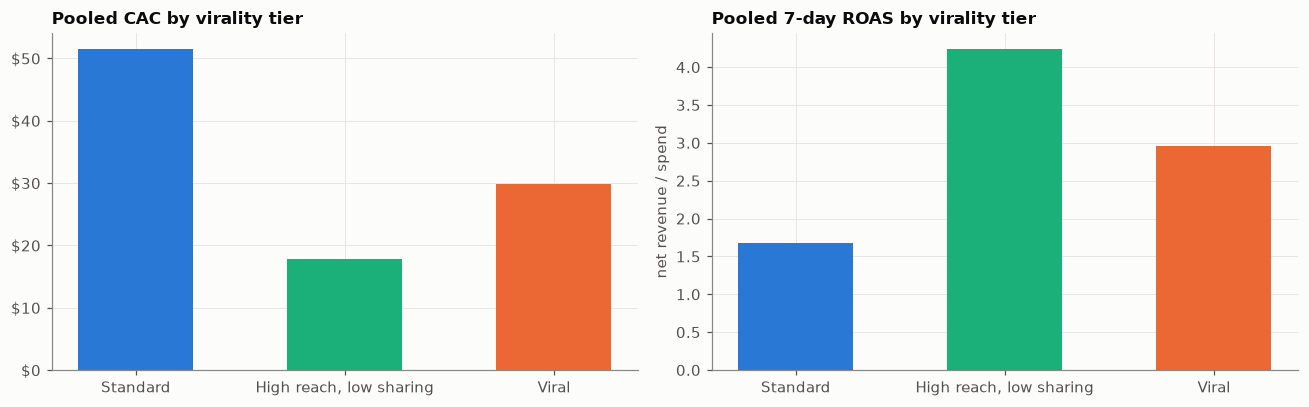

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
order = ["Standard", "High reach, low sharing", "Viral"]
cols = [viz.SERIES[0], viz.SERIES[2], viz.VIRAL]
ax[0].bar(order, short.loc[order, "cac_pooled"], color=cols, width=0.55); ax[0].yaxis.set_major_formatter(FuncFormatter(viz.money)); ax[0].set_title("Pooled CAC by virality tier")
ax[1].bar(order, short.loc[order, "roas_7d_pooled"], color=cols, width=0.55); ax[1].set_title("Pooled 7-day ROAS by virality tier"); ax[1].set_ylabel("net revenue / spend")
plt.tight_layout(); plt.savefig("../images/03_short_term_scorecard.png"); plt.show()

In [12]:
sc.sort_values("revenue_7d", ascending=False)[["campaign_id", "virality_tier", "campaign_type", "content_type", "creator_tier",
                                                "discount_pct", "reach", "spend", "new_customers", "cac", "revenue_7d", "roas_7d"]].head(12).round(2)

,campaign_id,virality_tier,campaign_type,content_type,creator_tier,discount_pct,reach,spend,new_customers,cac,revenue_7d,roas_7d
37,IG_038,Viral,Paid Amplification,Carousel,Brand,15,4143880,31227.49,4535,6.89,413316.92,13.24
87,IG_088,Standard,Product Drop,Carousel,Brand,0,730736,10597.58,1256,8.44,183603.79,17.33
38,IG_039,"High reach, low sharing",Influencer,Reel,Mid,15,1683594,9718.99,1793,5.42,164485.66,16.92
46,IG_047,Standard,Influencer,Story,Mega,10,1164903,79327.19,2382,33.30,151975.54,1.92
30,IG_031,"High reach, low sharing",Paid Amplification,Reel,Brand,0,3702945,46916.87,2169,21.63,131113.44,2.79
118,IG_119,Standard,Paid Amplification,Reel,Brand,0,1181546,29783.08,834,35.71,121208.33,4.07
91,IG_092,Standard,Paid Amplification,Reel,Brand,10,947179,40513.39,1217,33.29,107524.03,2.65
2,IG_003,Viral,Influencer,Reel,Macro,0,10191099,24736.95,1059,23.36,106138.92,4.29
5,IG_006,"High reach, low sharing",Product Drop,Reel,Brand,0,2371617,10751.22,1189,9.04,93183.68,8.67
51,IG_052,Standard,Discount,Reel,Brand,20,841584,5899.65,1041,5.67,85028.82,14.41


In [13]:
c.to_csv("../data/processed/campaigns_virality.csv", index=False)
sc.to_csv("../data/processed/campaign_short_term.csv", index=False)

**Takeaways.**
- By the reach + share-rate definition, a small minority of campaigns are viral and they are a *mixed* group
  (organic, influencer, paid, discount) whose save rates differ by 10×.
- Viral campaigns convert a smaller share of their reach, but their scale still gives them **lower CAC and
  higher 7-day ROAS** than standard campaigns. On short-term metrics, virality wins.
- For every tier the cohort's revenue is concentrated in the first week and decays quickly. Whether the spike
  turns into durable value is the next notebook's question.